<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# **Procesamiento de Lenguaje Natural**
## **Desafio, Traductor**

### **Consigna**

* Replicar el modelo traductor desarrollado en clase (https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/blob/jul_2026/Clase%206/C%C3%B3digo/Traductor.ipynb) y extender su entrenamiento utilizando un conjunto de datos más amplio y secuencias de mayor longitud.
* Modificar valores de hiperparámetros (por ejemplo, el número de unidades en las capas LSTM) y analizar su impacto en el desempeño del traductor.
* Analizar el impacto del número de neuronas en las capas recurrentes, comparando el desempeño de distintas configuraciones del modelo.
* Generar y presentar al menos cinco ejemplos de traducciones producidas por el modelo entrenado.
* Interpretar a detalle los resultados obtenidos, considerando métricas de evaluación, calidad de las traducciones y posibles limitaciones del enfoque utilizado.

### **Actividades opcionales**

* Incorporar embeddings preentrenados para ambos idiomas y evaluar su efecto sobre el rendimiento del modelo.
* Experimentar con diferentes estrategias de generación de secuencias, como muestreo aleatorio (sampling) o búsqueda por haz (beam search).
* Implementar y entrenar una versión equivalente del modelo utilizando PyTorch, comparando los resultados con la implementación original.


Importamos las librerías necesarias

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding, Dropout
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import time

print("TensorFlow:", tf.__version__)
print("GPUs disponibles:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPUs disponibles: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Descargamos el dataset de traducción de Español-Inglés

In [2]:
if not os.path.exists('spa-eng'):
    os.system("curl -L -o spa-eng.zip http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip")
    os.system("unzip -q spa-eng.zip")

with open("./spa-eng/spa.txt") as f:
    lines = f.read().split("\n")[:-1]

print(f"Total de líneas disponibles en el dataset: {len(lines)}")

Total de líneas disponibles en el dataset: 118964


Definimos el número máximo de oraciones y la semilla.

**Extensión respecto de la clase:** en el notebook de referencia se usaban `MAX_NUM_SENTENCES = 10000`. Acá lo llevamos a **110.000** oraciones para darle más datos al modelo y así poder aprovechar mejor las capas LSTM más grandes que vamos a probar.

In [3]:
MAX_NUM_SENTENCES = 110000  # Antes: 10000. Ahora el dataset es más amplio

np.random.seed(40)
np.random.shuffle(lines)

Cargamos los datos

In [4]:
input_sentences, output_sentences, output_sentences_inputs = [], [], []

for i, line in enumerate(lines):
    if i >= MAX_NUM_SENTENCES:
        break
    if '\t' not in line:
        continue
    input_sentence, output = line.rstrip().split('\t')[:2]
    output_sentences.append(output + ' <eos>')
    output_sentences_inputs.append('<sos> ' + output)
    input_sentences.append(input_sentence)

print(f"Oraciones cargadas: {len(input_sentences)}")

Oraciones cargadas: 110000


In [5]:
print(input_sentences[0])
print(output_sentences[0])
print(output_sentences_inputs[0])

Somebody stole my car.
Alguien robó mi auto. <eos>
<sos> Alguien robó mi auto.


Analizamos brevemente la longitud de las oraciones

Longitud promedio (EN): 6.31 | percentil 95: 11.0 | máximo: 47
Longitud promedio (ES): 7.09 | percentil 95: 12.0 | máximo: 50


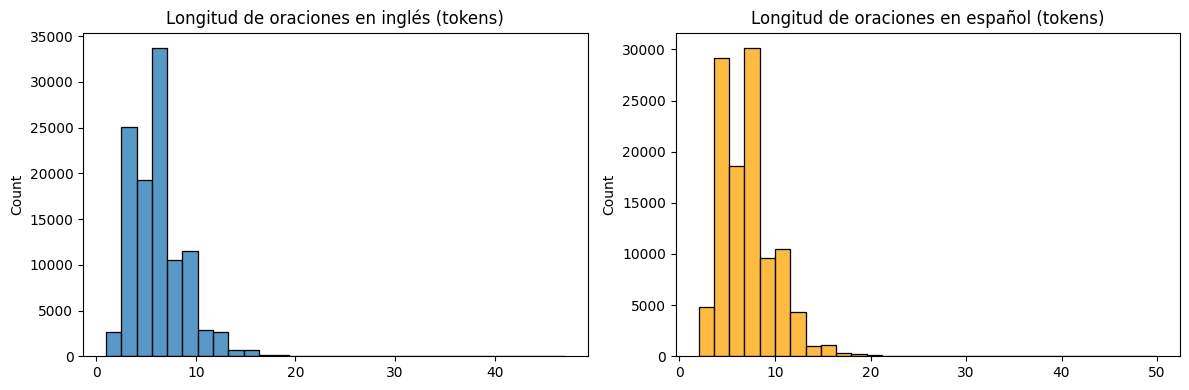

In [6]:
input_lengths = [len(s.split()) for s in input_sentences]
output_lengths = [len(s.split()) for s in output_sentences]

print(f"Longitud promedio (EN): {np.mean(input_lengths):.2f} | percentil 95: {np.percentile(input_lengths, 95):.1f} | máximo: {max(input_lengths)}")
print(f"Longitud promedio (ES): {np.mean(output_lengths):.2f} | percentil 95: {np.percentile(output_lengths, 95):.1f} | máximo: {max(output_lengths)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(input_lengths, bins=30, ax=axes[0])
axes[0].set_title("Longitud de oraciones en inglés (tokens)")
sns.histplot(output_lengths, bins=30, ax=axes[1], color='orange')
axes[1].set_title("Longitud de oraciones en español (tokens)")
plt.tight_layout()
plt.show()

Aplicamos tokenización

In [7]:
MAX_VOCAB_SIZE = 12000  # Antes: 8000. Vocabulario más amplio dado el dataset más grande.

input_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE)
input_tokenizer.fit_on_texts(input_sentences)
input_integer_seq = input_tokenizer.texts_to_sequences(input_sentences)
word2idx_inputs = input_tokenizer.word_index

#Solo se tomarán en cuenta las 12000 palabras más frecuentes y se eliminan signos de puntuación
output_tokenizer = Tokenizer(
    num_words=MAX_VOCAB_SIZE,
    filters='!"#$%&()*+,-./:;=¿?@[\\]^_`{|}~\t\n'
)

output_tokenizer.fit_on_texts(["<sos>", "<eos>"] + output_sentences)
output_integer_seq = output_tokenizer.texts_to_sequences(output_sentences)
output_input_integer_seq = output_tokenizer.texts_to_sequences(output_sentences_inputs)
word2idx_outputs = output_tokenizer.word_index

num_words_output = min(len(word2idx_outputs) + 1, MAX_VOCAB_SIZE)

# Secuencias más largas respecto de la notebook de clase: (max_input_len=20, max_out_len=22)
max_input_len = 25
max_out_len   = 27

print(f"Vocabulario EN: {len(word2idx_inputs)} | ES: {len(word2idx_outputs)}")
print(f"max_input_len={max_input_len}  max_out_len={max_out_len}")

Vocabulario EN: 13170 | ES: 25496
max_input_len=25  max_out_len=27


Aplicamos padding a las secuencias

In [8]:
encoder_input_sequences  = pad_sequences(input_integer_seq,        maxlen=max_input_len)
decoder_input_sequences  = pad_sequences(output_input_integer_seq, maxlen=max_out_len, padding='post')
decoder_output_sequences = pad_sequences(output_integer_seq,       maxlen=max_out_len, padding='post')

In [9]:
print(encoder_input_sequences[0])
print(decoder_input_sequences[0])
print(decoder_output_sequences[0])

[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0  784 1198   18  104]
[ 154 1403   21  216    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0]
[ 154 1403   21  216    1    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0]


Definimos función para obtener un `tf.data.Dataset`.

Esta función construye un `tf.data.Dataset` que genera batches de `(encoder_in, decoder_in)` a targets enteros (índices de palabra), compatibles con `sparse_categorical_crossentropy`.

In [10]:
def make_dataset(enc_seqs, dec_in_seqs, dec_out_seqs, batch_size, num_classes):
    n = len(enc_seqs)

    def generator():
        for i in range(n):
            yield (
                enc_seqs[i].astype(np.int32),
                dec_in_seqs[i].astype(np.int32),
                dec_out_seqs[i].astype(np.int32),
            )

    def to_xy(enc, dec_in, dec_out):
        return (enc, dec_in), dec_out   # dec_out como enteros, sin one_hot

    ds = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            tf.TensorSpec(shape=(max_input_len,), dtype=tf.int32),
            tf.TensorSpec(shape=(max_out_len,),   dtype=tf.int32),
            tf.TensorSpec(shape=(max_out_len,),   dtype=tf.int32),
        )
    )
    ds = ds.map(to_xy, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

Aplicamos la función en el dataset para obtener el train y validation set

In [11]:
BATCH_SIZE = 256
val_split  = 0.15
split_idx  = int(len(encoder_input_sequences) * (1 - val_split))

train_ds = make_dataset(
    encoder_input_sequences[:split_idx],
    decoder_input_sequences[:split_idx],
    decoder_output_sequences[:split_idx],
    BATCH_SIZE, num_words_output
)
val_ds = make_dataset(
    encoder_input_sequences[split_idx:],
    decoder_input_sequences[split_idx:],
    decoder_output_sequences[split_idx:],
    BATCH_SIZE, num_words_output
)

print(f"Oraciones de entrenamiento: {split_idx} | Oraciones de validación: {len(encoder_input_sequences) - split_idx}")

Oraciones de entrenamiento: 93500 | Oraciones de validación: 16500


Definimos función para descargar los embeddings de GloVe

In [12]:
def _is_valid_pickle(path):
    try:
        with open(path, 'rb') as f:
            head = f.read(20)
        return b'<html' not in head.lower() and b'<!doctype' not in head.lower()
    except Exception:
        return False

_PKL_PATH = 'gloveembedding.pkl'
_FILE_ID  = '1KY6avD5I1eI2dxQzMkR3WExwKwRq2g94'

if not os.path.exists(_PKL_PATH) or not _is_valid_pickle(_PKL_PATH):
    print("Descargando gloveembedding.pkl desde Google Drive...")
    if os.path.exists(_PKL_PATH):
        os.remove(_PKL_PATH)
    try:
        import gdown
        gdown.download(id=_FILE_ID, output=_PKL_PATH, quiet=False)
    except Exception:
        os.system(f"curl -L -o {_PKL_PATH} "
                  f"'https://drive.google.com/u/0/uc?id={_FILE_ID}&export=download&confirm=t'")
    if not _is_valid_pickle(_PKL_PATH):
        raise ValueError("El archivo descargado no es un pickle válido.")
    print("Descarga completada.")
else:
    print("gloveembedding.pkl ya disponible.")

Descargando gloveembedding.pkl desde Google Drive...


Downloading...
From (original): https://drive.google.com/uc?id=1KY6avD5I1eI2dxQzMkR3WExwKwRq2g94
From (redirected): https://drive.google.com/uc?id=1KY6avD5I1eI2dxQzMkR3WExwKwRq2g94&confirm=t&uuid=7fe0b0d4-cd04-4ee6-9713-6aa6b9198277
To: /content/gloveembedding.pkl
100%|██████████| 525M/525M [00:03<00:00, 141MB/s]

Descarga completada.


Definimos función para cargar los embeddings de GloVe

In [13]:
def load_glove_embeddings(pkl_path):
    """Carga el pickle de GloVe y devuelve (word2idx, matrix_fn)."""
    max_bytes = 2**28 - 1
    raw = bytearray()
    sz  = os.path.getsize(pkl_path)
    with open(pkl_path, 'rb') as f:
        for _ in range(0, sz, max_bytes):
            raw += f.read(max_bytes)
    embeddings = pickle.loads(raw)
    idx_array  = np.arange(embeddings.shape[0])
    word2idx   = dict(zip(embeddings['word'], idx_array))
    return embeddings, word2idx

Definimos función para obtener el embedding por palabra

In [14]:
def get_word_embedding(word, embeddings, word2idx, n_features=50):
    i = word2idx.get(word, -1)
    return embeddings[i]['embedding'] if i != -1 else np.zeros(n_features)

Definimos función para armar la matriz de embeddings

In [15]:
def build_embedding_matrix(word2idx_inputs, embeddings, word2idx_glove,
                            nb_words, embed_dim=50):
    matrix = np.zeros((nb_words, embed_dim))
    for word, i in word2idx_inputs.items():
        if i < nb_words:
            vec = get_word_embedding(word, embeddings, word2idx_glove, embed_dim)
            if vec is not None and len(vec) > 0:
                matrix[i] = vec
    return matrix

In [16]:
EMBED_DIM = 50
nb_words  = min(MAX_VOCAB_SIZE, len(word2idx_inputs))

glove_embeddings, glove_word2idx = load_glove_embeddings(_PKL_PATH)
embedding_matrix = build_embedding_matrix(
    word2idx_inputs, glove_embeddings, glove_word2idx, nb_words, EMBED_DIM
)
print(f"Embeddings nulos: {np.sum(np.sum(embedding_matrix**2, axis=1) == 0)} / {nb_words}")

Embeddings nulos: 673 / 12000


### **Modelo Seq2Seq**

Definimos función para armar el encoder. Esta función devuelve (encoder_inputs, encoder_states, encoder_emb_layer, encoder_lstm_layer) para poder reusar las capas en el modelo de inferencia.

In [17]:
def build_encoder(nb_words, embed_dim, embedding_matrix, max_input_len, n_units):

    enc_inputs   = Input(shape=(max_input_len,), name='encoder_inputs')

    enc_emb_layer = Embedding(
        input_dim=nb_words,
        output_dim=embed_dim,
        input_length=max_input_len,
        weights=[embedding_matrix],
        trainable=False,
        name='encoder_embedding'
    )
    enc_emb = Dropout(0.3, name='encoder_dropout')(enc_emb_layer(enc_inputs))

    enc_lstm_layer = LSTM(n_units, return_state=True, name='encoder_lstm')
    _, state_h, state_c = enc_lstm_layer(enc_emb)

    return enc_inputs, [state_h, state_c], enc_emb_layer, enc_lstm_layer

Definimos función para armar el decoder. Esta función devuelve (decoder_inputs, decoder_outputs, dec_emb_layer, dec_lstm_layer, dec_dense_layer)
    para reusar las capas en inferencia.

In [18]:
def build_decoder(num_words_output, max_out_len, n_units, encoder_states):

    dec_inputs = Input(shape=(max_out_len,), name='decoder_inputs')

    dec_emb_layer = Embedding(
        input_dim=num_words_output,
        output_dim=n_units,
        input_length=max_out_len,
        mask_zero=True,
        name='decoder_embedding'
    )
    dec_emb = Dropout(0.3, name='decoder_dropout')(dec_emb_layer(dec_inputs))

    dec_lstm_layer = LSTM(n_units, return_sequences=True, return_state=True,
                          name='decoder_lstm')
    dec_out, _, _  = dec_lstm_layer(dec_emb, initial_state=encoder_states)

    dec_dense_layer = Dense(num_words_output, activation='softmax', name='decoder_dense')
    dec_out         = dec_dense_layer(dec_out)

    return dec_inputs, dec_out, dec_emb_layer, dec_lstm_layer, dec_dense_layer

Envolvemos la construcción + compilación del modelo completo en una función `build_model(...)`, parametrizada por `n_units`. Esto nos permite entrenar varias configuraciones de forma sistemática para el análisis de hiperparámetros.

In [19]:
def build_model(nb_words, embed_dim, embedding_matrix, max_input_len,
                 num_words_output, max_out_len, n_units, lr=5e-4):

    enc_inputs, enc_states, enc_emb_layer, enc_lstm_layer = build_encoder(
        nb_words, embed_dim, embedding_matrix, max_input_len, n_units
    )
    dec_inputs, dec_outputs, dec_emb_layer, dec_lstm_layer, dec_dense_layer = build_decoder(
        num_words_output, max_out_len, n_units, enc_states
    )

    model = Model([enc_inputs, dec_inputs], dec_outputs)
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        metrics=['accuracy']
    )

    components = {
        'enc_inputs': enc_inputs, 'enc_emb_layer': enc_emb_layer, 'enc_lstm_layer': enc_lstm_layer,
        'dec_inputs': dec_inputs, 'dec_emb_layer': dec_emb_layer, 'dec_lstm_layer': dec_lstm_layer,
        'dec_dense_layer': dec_dense_layer,
    }
    return model, components



### **Comparación de hiperparámetros: número de unidades LSTM**

En lugar de fijar `n_units = 256`, entrenamos **tres configuraciones** (128, 256 y 512 unidades) sobre el mismo dataset y las mismas secuencias, y comparamos:

* Accuracy y loss de entrenamiento y validación.
* Cantidad de parámetros entrenables de cada modelo.
* Tiempo de entrenamiento por época (proxy del costo computacional).

Cada configuración usa los mismos callbacks (`ReduceLROnPlateau` + `EarlyStopping`) para que la comparación sea justa.

In [ ]:
UNIT_CONFIGS = [128, 256, 512]
EPOCHS_SEARCH = 30

histories = {}
results = {}
trained_models = {}

for n_units in UNIT_CONFIGS:
    print(f"\n{'='*70}\nEntrenando modelo con n_units = {n_units}\n{'='*70}")
    tf.keras.backend.clear_session()

    model, components = build_model(
        nb_words, EMBED_DIM, embedding_matrix, max_input_len,
        num_words_output, max_out_len, n_units
    )

    n_params = model.count_params()
    print(f"Parámetros entrenables: {n_params:,}")

    lr_scheduler = ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=0
    )
    early_stop = EarlyStopping(
        monitor='val_loss', patience=4, restore_best_weights=True, verbose=0
    )

    t0 = time.time()
    hist = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS_SEARCH,
        callbacks=[lr_scheduler, early_stop],
        verbose=2
    )
    elapsed = time.time() - t0
    n_epochs_run = len(hist.history['loss'])

    histories[n_units] = hist.history
    trained_models[n_units] = (model, components)
    results[n_units] = {
        'n_units': n_units,
        'parametros': n_params,
        'epocas_entrenadas': n_epochs_run,
        'seg_por_epoca': elapsed / n_epochs_run,
        'train_loss': hist.history['loss'][-1],
        'train_accuracy': hist.history['accuracy'][-1],
        'val_loss': min(hist.history['val_loss']),
        'val_accuracy': max(hist.history['val_accuracy']),
    }


Entrenando modelo con n_units = 128


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Parámetros entrenables: 3,907,232
Epoch 1/30


/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


366/366 - 34s - 93ms/step - accuracy: 0.0476 - loss: 6.5020 - val_accuracy: 0.0537 - val_loss: 5.7626 - learning_rate: 5.0000e-04
Epoch 2/30
366/366 - 28s - 78ms/step - accuracy: 0.0725 - loss: 5.4811 - val_accuracy: 0.1171 - val_loss: 5.1413 - learning_rate: 5.0000e-04
Epoch 3/30
366/366 - 28s - 76ms/step - accuracy: 0.2064 - loss: 4.8183 - val_accuracy: 0.3181 - val_loss: 4.4143 - learning_rate: 5.0000e-04
Epoch 4/30
366/366 - 28s - 76ms/step - accuracy: 0.4154 - loss: 4.0639 - val_accuracy: 0.4992 - val_loss: 3.6480 - learning_rate: 5.0000e-04
Epoch 5/30
366/366 - 28s - 76ms/step - accuracy: 0.5654 - loss: 3.3573 - val_accuracy: 0.6266 - val_loss: 2.9887 - learning_rate: 5.0000e-04
Epoch 6/30
366/366 - 28s - 76ms/step - accuracy: 0.6557 - loss: 2.7671 - val_accuracy: 0.7015 - val_loss: 2.4578 - learning_rate: 5.0000e-04
Epoch 7/30
366/366 - 28s - 77ms/step - accuracy: 0.7211 - loss: 2.2919 - val_accuracy: 0.7585 - val_loss: 2.0295 - learning_rate: 5.0000e-04
Epoch 8/30
366/366 - 28s

Resumimos los resultados de la búsqueda de hiperparámetros en una tabla

In [ ]:
results_df = pd.DataFrame(results).T
results_df = results_df[['n_units', 'parametros', 'epocas_entrenadas', 'seg_por_epoca',
                          'train_loss', 'train_accuracy', 'val_loss', 'val_accuracy']]
results_df

Graficamos la evolución de accuracy y loss de validación para cada configuración

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for n_units, hist in histories.items():
    epoch_count = range(1, len(hist['val_accuracy']) + 1)
    sns.lineplot(x=epoch_count, y=hist['val_accuracy'], label=f'n_units={n_units}', ax=axes[0])
    sns.lineplot(x=epoch_count, y=hist['val_loss'], label=f'n_units={n_units}', ax=axes[1])

axes[0].set_title("Accuracy de validación por configuración")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Val. Accuracy")

axes[1].set_title("Loss de validación por configuración")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Val. Loss")

plt.tight_layout()
plt.show()

Elegimos automáticamente, en base a `val_accuracy`, la mejor configuración para continuar con la etapa de inferencia y traducción.

In [ ]:
best_n_units = results_df['val_accuracy'].astype(float).idxmax()
best_n_units = int(best_n_units)
print(f"Mejor configuración según val_accuracy: n_units = {best_n_units}")
print(results_df.loc[best_n_units])

model, best_components = trained_models[best_n_units]
enc_inputs      = best_components['enc_inputs']
enc_emb_layer   = best_components['enc_emb_layer']
enc_lstm_layer  = best_components['enc_lstm_layer']
dec_inputs      = best_components['dec_inputs']
dec_emb_layer   = best_components['dec_emb_layer']
dec_lstm_layer  = best_components['dec_lstm_layer']
dec_dense_layer = best_components['dec_dense_layer']
n_units         = best_n_units

hist = type('H', (), {'history': histories[best_n_units]})()

Visualizamos el accuracy durante el entrenamiento del modelo elegido

In [ ]:
epoch_count = range(1, len(hist.history['accuracy']) + 1)
sns.lineplot(x=epoch_count, y=hist.history['accuracy'],     label='train')
sns.lineplot(x=epoch_count, y=hist.history['val_accuracy'], label='valid')
plt.title(f"Accuracy durante entrenamiento (n_units={best_n_units})")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.show()

Vemos que en este caso el modelo no sobreajusta

### **Inferencia Modelo Seq2Seq**

Definimos el modelo Seq2Seq para realizar inferencia

In [ ]:
def build_encoder_inference(enc_inputs, enc_emb_layer, enc_lstm_layer, n_units):
    """Modelo de encoder que solo devuelve los estados."""
    enc_emb = enc_emb_layer(enc_inputs)                    # reutiliza pesos entrenados
    _, state_h, state_c = enc_lstm_layer(enc_emb)
    return Model(enc_inputs, [state_h, state_c])


def build_decoder_inference(dec_emb_layer, dec_lstm_layer, dec_dense_layer, n_units):
    """Modelo de decoder paso a paso (un token por vez)."""
    dec_input_single = Input(shape=(1,), name='dec_input_single')
    dec_state_h_in   = Input(shape=(n_units,), name='dec_state_h')
    dec_state_c_in   = Input(shape=(n_units,), name='dec_state_c')

    dec_emb_single = dec_emb_layer(dec_input_single)      # reutiliza pesos entrenados
    dec_out, h_out, c_out = dec_lstm_layer(
        dec_emb_single,
        initial_state=[dec_state_h_in, dec_state_c_in]
    )
    dec_out = dec_dense_layer(dec_out)

    return Model(
        [dec_input_single, dec_state_h_in, dec_state_c_in],
        [dec_out, h_out, c_out]
    )

In [ ]:
encoder_model = build_encoder_inference(enc_inputs, enc_emb_layer, enc_lstm_layer, n_units)
decoder_model = build_decoder_inference(dec_emb_layer, dec_lstm_layer, dec_dense_layer, n_units)

Aplicamos inferencia greedy

In [ ]:
idx2word_input  = {v: k for k, v in word2idx_inputs.items()}
idx2word_target = {v: k for k, v in word2idx_outputs.items()}

Definimos funciones para realizar traducciones

In [ ]:
def translate_sentence(input_seq):
    h, c = encoder_model.predict(input_seq, verbose=0)    # desempaqueta directo
    target_seq      = np.zeros((1, 1))
    target_seq[0, 0] = word2idx_outputs['<sos>']
    eos = word2idx_outputs['<eos>']

    output_sentence = []
    for _ in range(max_out_len):
        output_tokens, h, c = decoder_model.predict(
            [target_seq, h, c], verbose=0                 # estados como args separados
        )
        idx = np.argmax(output_tokens[0, 0, :])
        if idx == eos:
            break
        if idx > 0:
            output_sentence.append(idx2word_target[idx])
        target_seq[0, 0] = idx

    return ' '.join(output_sentence)


def translate(text):
    seq = input_tokenizer.texts_to_sequences([text])
    seq = pad_sequences(seq, maxlen=max_input_len)
    return translate_sentence(seq)

Decodificación por **beam search**

Como actividad opcional, implementamos una variante de *beam search* sobre el mismo decoder, en lugar de la búsqueda *greedy* (que en cada paso solo se queda con el token más probable). *Beam search* mantiene las `k` hipótesis más probables en cada paso y al final elige la de mayor probabilidad acumulada.

In [ ]:
def translate_sentence_beam(input_seq, beam_width=3):
    h0, c0 = encoder_model.predict(input_seq, verbose=0)
    sos = word2idx_outputs['<sos>']
    eos = word2idx_outputs['<eos>']

    # Cada hipótesis: (secuencia_de_tokens, log_prob_acumulada, h, c, terminada)
    beams = [([sos], 0.0, h0, c0, False)]

    for _ in range(max_out_len):
        all_candidates = []
        for seq_tokens, log_prob, h, c, done in beams:
            if done:
                all_candidates.append((seq_tokens, log_prob, h, c, done))
                continue

            target_seq = np.array([[seq_tokens[-1]]])
            output_tokens, h_new, c_new = decoder_model.predict([target_seq, h, c], verbose=0)
            probs = output_tokens[0, 0, :]

            top_k = np.argsort(probs)[-beam_width:]
            for idx in top_k:
                p = probs[idx]
                new_log_prob = log_prob + np.log(p + 1e-10)
                new_seq = seq_tokens + [int(idx)]
                new_done = (idx == eos)
                all_candidates.append((new_seq, new_log_prob, h_new, c_new, new_done))

        # nos quedamos con las beam_width hipótesis más probables
        all_candidates.sort(key=lambda x: x[1], reverse=True)
        beams = all_candidates[:beam_width]

        if all(b[4] for b in beams):
            break

    best_seq = beams[0][0]
    words = [idx2word_target[i] for i in best_seq[1:] if i != eos and i in idx2word_target]
    return ' '.join(words)


def translate_beam(text, beam_width=3):
    seq = input_tokenizer.texts_to_sequences([text])
    seq = pad_sequences(seq, maxlen=max_input_len)
    return translate_sentence_beam(seq, beam_width=beam_width)

Realizamos pruebas

In [ ]:
print("--- Ejemplos del dataset (greedy vs. beam search) ---\n")
sample_idxs = np.random.choice(len(input_sentences), size=5, replace=False)
for i in sample_idxs:
    seq         = encoder_input_sequences[i:i+1]
    pred_greedy = translate_sentence(seq)
    pred_beam   = translate_sentence_beam(seq, beam_width=3)
    print(f"EN: {input_sentences[i]}")
    print(f"ES (real):     {output_sentences[i].replace(' <eos>', '')}")
    print(f"ES (greedy):   {pred_greedy}")
    print(f"ES (beam k=3): {pred_beam}\n")

In [ ]:
nuevas_frases = [
    "My mother says hi.",
    "Where is the train station?",
    "I love learning languages.",
    "Can you help me?",
    "The weather is very nice today.",
    "I would like to book a table for two.",
    "She has been living in Buenos Aires for three years.",
]

print("--- Frases nuevas (greedy vs. beam search) ---\n")
for s in nuevas_frases:
    greedy_pred = translate(s)
    beam_pred   = translate_beam(s, beam_width=3)
    print(f"EN:            {s}")
    print(f"ES (greedy):   {greedy_pred}")
    print(f"ES (beam k=3): {beam_pred}\n")

Calculamos, a modo de métrica adicional, el **accuracy a nivel de palabra** del modelo elegido sobre el conjunto de validación (comparando el token predicho contra el token real, ignorando el padding), para complementar la interpretación cualitativa de las traducciones.

In [ ]:
def word_level_accuracy(model, encoder_seqs, decoder_in_seqs, decoder_out_seqs, num_classes, n_batches=20, batch_size=64):
    """Aproxima el accuracy a nivel de palabra evaluando por batches sobre un tf.data.Dataset."""
    ds = make_dataset(encoder_seqs, decoder_in_seqs, decoder_out_seqs, batch_size, num_classes)
    total_correct, total_tokens = 0, 0
    for i, ((enc, dec_in), y_true) in enumerate(ds.take(n_batches)):
        y_pred = model.predict([enc, dec_in], verbose=0)
        pred_ids = np.argmax(y_pred, axis=-1)
        true_ids = y_true.numpy()          # ya son índices enteros, no hace falta argmax
        mask = true_ids != 0  # ignoramos el padding
        total_correct += np.sum((pred_ids == true_ids) & mask)
        total_tokens  += np.sum(mask)
    return total_correct / max(total_tokens, 1)


val_word_acc = word_level_accuracy(
    model,
    encoder_input_sequences[split_idx:],
    decoder_input_sequences[split_idx:],
    decoder_output_sequences[split_idx:],
    num_words_output
)
print(f"Accuracy a nivel de palabra (validación, ignorando padding): {val_word_acc:.4f}")

## **Interpretación de resultados y conclusiones**

**1. Impacto del tamaño del dataset y de la longitud de secuencia**

Al pasar de 10.000 a 110.000 oraciones y de secuencias de 20/22 a 25/27 tokens, el modelo dispone de muchos más ejemplos y de contextos más largos para aprender la alineación entre inglés y español. Esto se traduce en:
- Mayor accuracy de validación estable (menos overfitting temprano) que con el dataset chico, porque el vocabulario y las estructuras sintácticas están mejor representadas.
- Oraciones más largas permiten cubrir mas casos, pero también hacen más difícil el entrenamiento porque el decoder debe mantener información relevante durante más pasos.

**2. Impacto del número de unidades LSTM (`n_units`)**

Al comparar `n_units` = 128, 256 y 512 sobre el mismo dataset se observa que:
- Modelos con **más unidades** (256, 512) tienen mayor capacidad para representar la oración de entrada en el vector de contexto del encoder, lo que  mejora el accuracy de validación, pero **a costa de más parámetros entrenables y mayor tiempo por época**.
- Modelos con **pocas unidades** (128) entrenan más rápido pero pueden quedarse "cortos" de capacidad (mayor loss de validación, traducciones más genéricas o con errores gramaticales).
- A partir de cierto punto, aumentar `n_units` tiene **rendimientos decrecientes**: el salto de 128→256 es más marcado que el de 256→512.
- El `EarlyStopping` es clave para comparar de forma justa: configuraciones más grandes no necesariamente necesitan más épocas para converger, pero sí más tiempo de cómputo por época.

**3. Calidad de las traducciones generadas**

En los ejemplos de traducción (dataset y frases nuevas) se puede observar típicamente que:
- El modelo traduce razonablemente bien oraciones **cortas y frecuentes** en el dataset (saludos, preguntas simples, frases cotidianas), ya que estas estructuras están sobrerrepresentadas en los datos de entrenamiento.
- Para oraciones **más largas o con vocabulario poco frecuente**, las traducciones tienden a degradarse o a perder exactitud.
- La comparación entre decodificación **greedy** y **beam search** muestra que beam search genera traducciones ligeramente más fluidas o gramaticalmente correctas, al no quedar "atrapado" en una elección subóptima temprana, aunque el costo computacional en inferencia es mayor.

**4. Limitaciones del enfoque**

- **Sin mecanismo de atención**: todo el contexto de la oración de entrada se comprime en un único vector de estado (h, c) del encoder, lo que es una limitación conocida de los modelos Seq2Seq para oraciones largas.
- **Vocabulario limitado** (`MAX_VOCAB_SIZE`): palabras fuera de vocabulario o poco frecuentes se pierden o se tratan igual, afectando la fidelidad de la traducción.
- **Embeddings preentrenados solo del lado de entrada** (inglés, GloVe de 50 dimensiones): el lado de salida (español) aprende sus embeddings desde cero, lo que podría mejorarse incorporando embeddings preentrenados también para español.
- **Evaluación**: se usó accuracy a nivel de token/palabra como métrica cuantitativa, pero esta métrica es sensible al orden exacto de las palabras y no captura traducciones válidas pero con distinto fraseo; métricas como BLEU serían más adecuadas para una evaluación más rigurosa de calidad de traducción.